# Скоринговая модель для микрофинансирования


**Задача.** Бинарная классификация: предсказать дефолт заёмщика по анкете кредитной заявки.

**Датасет.** Home Credit Default Risk (Kaggle), таблица `application_train.csv` — 307 511 заявок, 122 колонки.

**Целевая переменная.** `TARGET`: 1 — клиент допустил просрочку, 0 — платил без задержек. Классы сильно несбалансированы (~8% единиц).

**Метрика** соревнования - ROC-AUC

In [1]:
import time
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

SEED = 42

results = {}

## 1. EDA и предобработка

### 1.1 Загрузка данных

`SK_ID_CURR` — технический идентификатор заявки, предсказательной силы не несёт и удаляется сразу,

In [2]:
df = pd.read_csv('application_train.csv')
df = df.drop('SK_ID_CURR', axis=1)
print(df.shape)
df.head()

(307511, 121)


,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.2 Целевая переменная

Проверяем баланс классов.

TARGET
0    282686
1     24825
Name: count, dtype: int64
доля дефолтов: 8.07%


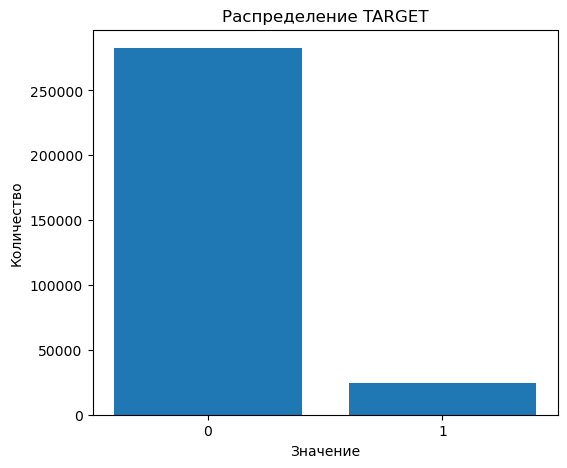

In [3]:
Y = df['TARGET']
X = df.drop('TARGET', axis=1)

counts = Y.value_counts()
print(counts)
print(f"доля дефолтов: {Y.mean():.2%}")

fig, ax = plt.subplots(figsize=(6,5))
ax.bar(counts.index.astype(str), counts.values)
ax.set_ylabel('Количество')
ax.set_xlabel('Значение')
ax.set_title('Распределение TARGET')
plt.show()

Классы несбалансированы примерно 1:11.

### 1.3 Типы признаков и пропуски

In [4]:
print(df.dtypes.value_counts())

na = X.isna().mean().sort_values(ascending=False)
print(f"\nколонок с пропусками: {(na > 0).sum()} из {X.shape[1]}")
na[na > 0].head(15)

float64    65
int64      40
object     16
Name: count, dtype: int64

колонок с пропусками: 67 из 120


COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_AVG             0.664978
dtype: float64

Пропусков много, и они сосредоточены в двух группах:

- **блок описания жилья** (`*_AVG`, `*_MODE`, `*_MEDI`) — 50–70% пропусков;
- **`EXT_SOURCE_1/3`** — внешние кредитные рейтинги, 20–56% пропусков.

Все пропуски заполняются **внутри пайплайна** (`SimpleImputer` как шаг `ColumnTransformer`),
а не заранее по всему датафрейму — иначе статистики считались бы по всей выборке,
включая валидационные фолды, что дало бы утечку данных.

### 1.4 Категориальные признаки

Константные колонки (`nunique <= 1`) удаляются: они не несут информации, но раздувают матрицу после OHE.

In [5]:
feach_drop = [c for c in X.columns if X[c].nunique() <= 1]
X = X.drop(feach_drop, axis=1)

cat_cols = X.select_dtypes(include=['object', 'string']).columns
target = [c for c in cat_cols if X[c].nunique() >= 10]
ohe = [c for c in cat_cols if X[c].nunique() < 10]
categor = target + ohe
print('удалено константных:', len(feach_drop), '| категориальных:', len(categor))
print('высококардинальные:', target)

удалено константных: 0 | категориальных: 16
высококардинальные: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


### 1.5 Выбросы

Смотрим боксплоты по всем числовым признакам, чтобы найти те, где хвост распределения явно аномальный.

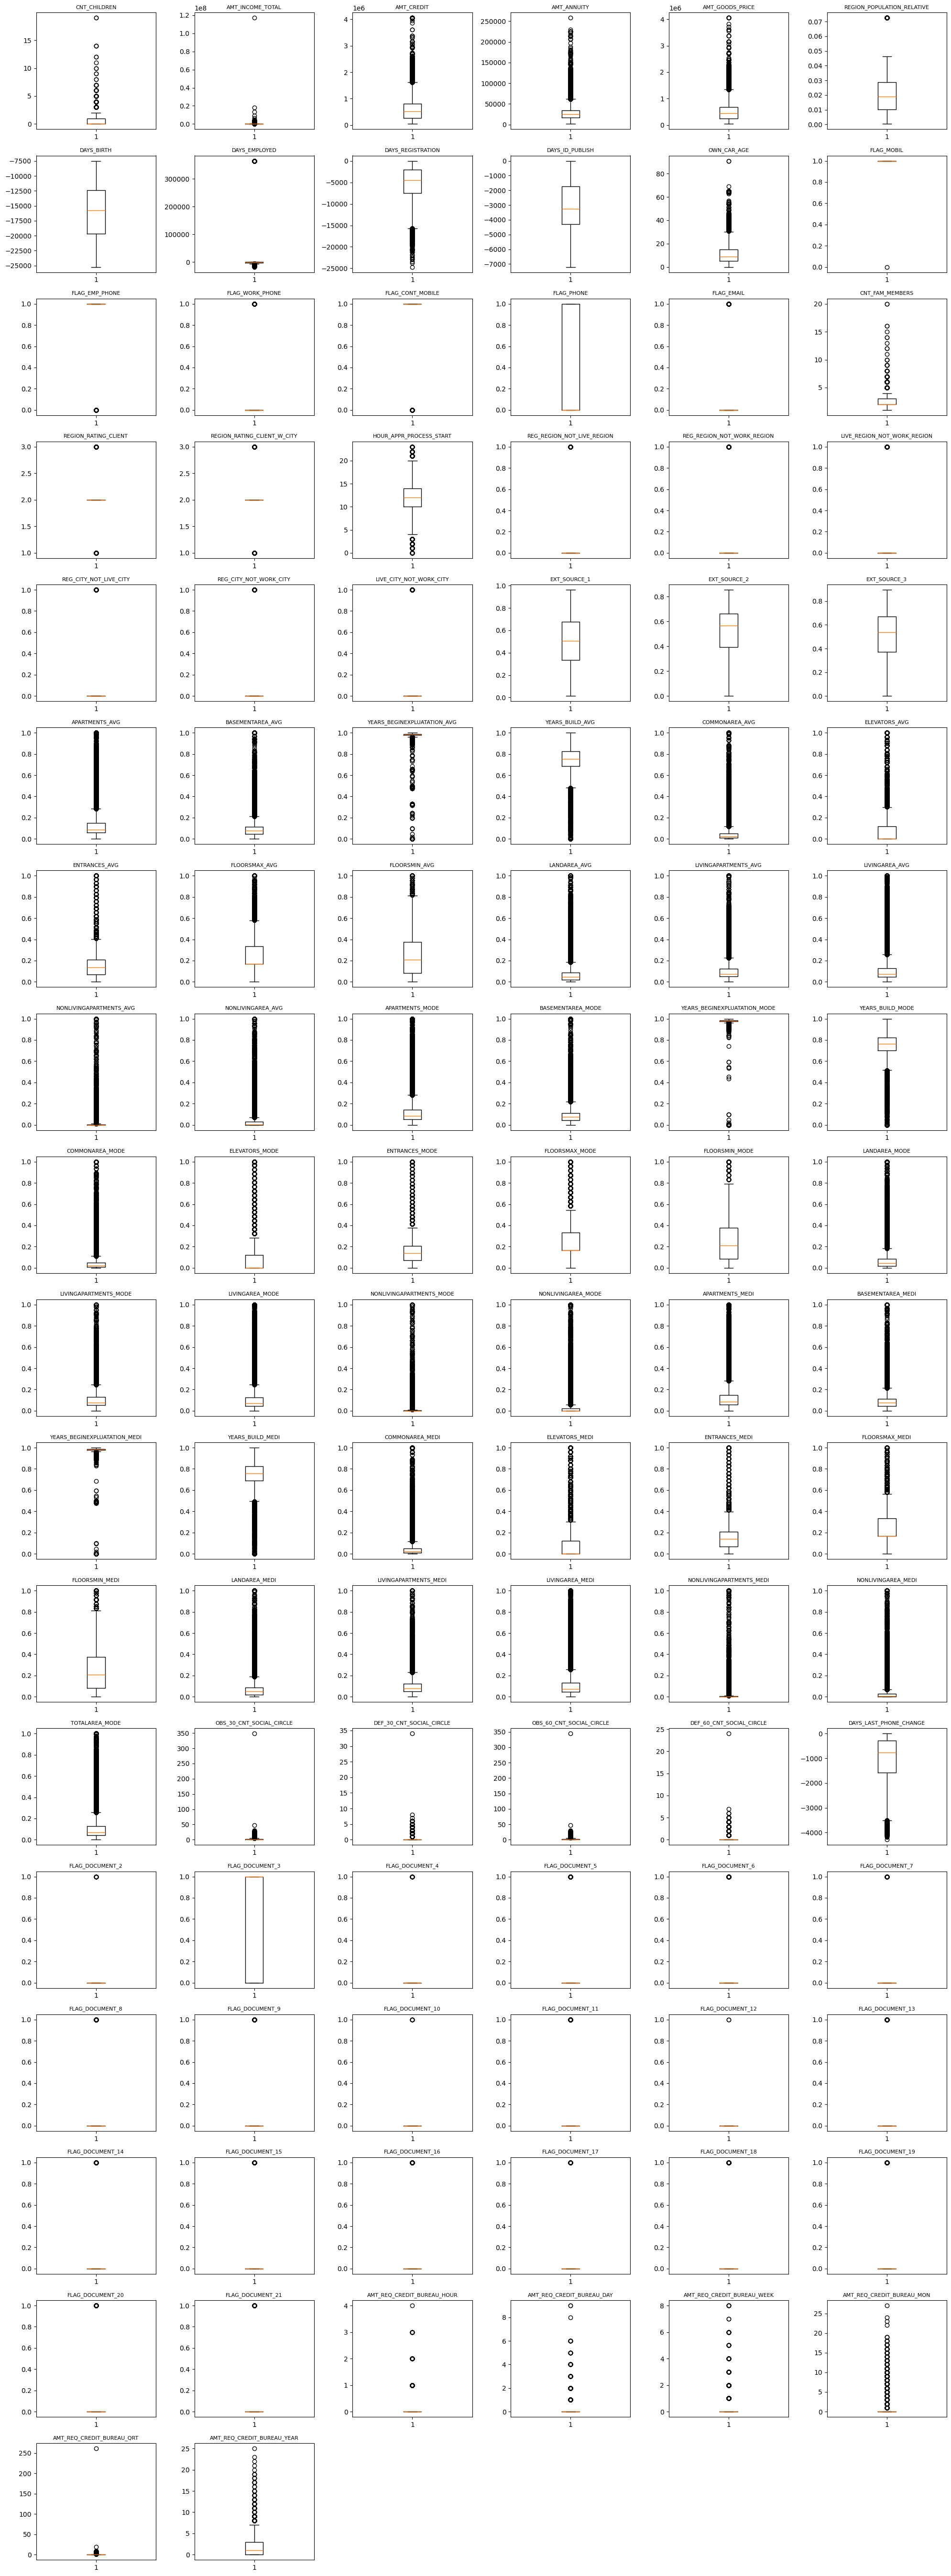

In [6]:
numeric = X.select_dtypes(include='number').columns

n_cols = 6
n_rows = -(-len(numeric) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()
for i, key in enumerate(numeric):
    axes[i].boxplot(X[key].dropna())
    axes[i].set_title(key, fontsize=8)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Обрезаем по 1-му и 99-му перцентилю три признака с самыми тяжёлыми хвостами.
Клиппинг нужен в первую очередь для MLP и логистической регрессии — деревья к выбросам почти нечувствительны,
но экстремальные значения ломают масштабирование и градиенты в нейросети.

In [7]:
cols_to_clip = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'CNT_FAM_MEMBERS']
for key in cols_to_clip:
    lower = X[key].quantile(0.01)
    upper = X[key].quantile(0.99)
    X[key] = X[key].clip(lower, upper)

### 1.6 Feature engineering

Пять новых признаков. Абсолютные суммы (доход, размер кредита, платёж) сами по себе говорят мало —
кредит в 1 млн для человека с доходом 200 тыс. и с доходом 2 млн означает совершенно разный уровень риска.
Поэтому строим **отношения**, которые как раз и используют кредитные аналитики:

| Признак | Формула | Смысл |
|---|---|---|
| `CREDIT_INCOME_RATE` | кредит / доход | во сколько раз кредит больше годового дохода |
| `ANNUITY_INCOME_RATE` | платёж / доход | долговая нагрузка, ключевой показатель в скоринге |
| `CREDIT_ANNUITY_RATIO` | кредит / платёж | фактический срок кредита в периодах |
| `CREDIT_GOODS_RATIO` | кредит / цена товара | переплата, косвенный признак первого взноса |
| `INCOME_PER_PERSON` | доход / размер семьи | доход на одного члена семьи |

Деления дают `inf` там, где знаменатель равен нулю; их нужно превратить в `NaN`,
иначе `SimpleImputer(strategy='mean')` посчитает среднее равным бесконечности и испортит весь столбец.

In [8]:
new_feaches = pd.DataFrame({
    'CREDIT_INCOME_RATE': X['AMT_CREDIT'] / X['AMT_INCOME_TOTAL'],
    'ANNUITY_INCOME_RATE' : X['AMT_ANNUITY'] / X['AMT_INCOME_TOTAL'],
    'CREDIT_ANNUITY_RATIO' : X['AMT_CREDIT'] / X['AMT_ANNUITY'],
    'CREDIT_GOODS_RATIO' : X['AMT_CREDIT'] / X['AMT_GOODS_PRICE'],
    'INCOME_PER_PERSON' : X['AMT_INCOME_TOTAL'] / X['CNT_FAM_MEMBERS']
})
new_feaches = new_feaches.replace([np.inf, -np.inf], np.nan)
X = pd.concat([X, new_feaches], axis=1)

numeric = X.select_dtypes(include='number').columns
print('числовых признаков:', len(numeric))

числовых признаков: 109


### 1.7 Корреляции с целевой переменной

In [9]:
correlations = X[numeric].corrwith(Y).sort_values(key=abs, ascending=False)
correlations.head(15)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_BIRTH                     0.078239
CREDIT_GOODS_RATIO             0.064483
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                 -0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                 -0.044003
dtype: float64

Корреляционная матрица топ-признаков — проверяем, не дублируют ли они друг друга.

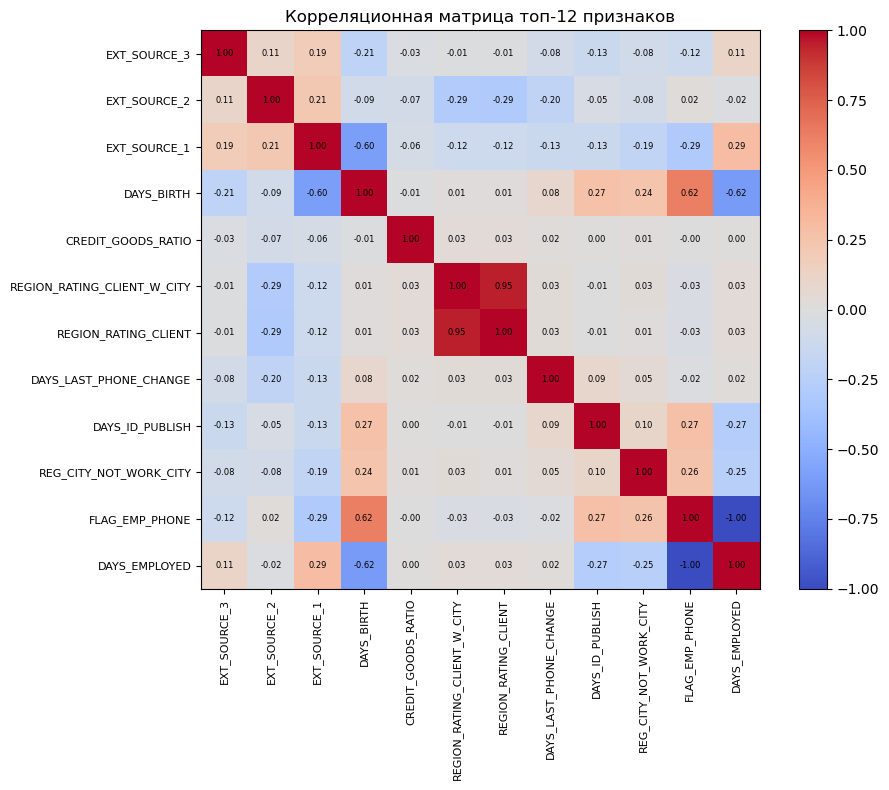

In [10]:
top_corr_cols = correlations.head(12).index.tolist()
corr_matrix = X[top_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top_corr_cols)))
ax.set_yticks(range(len(top_corr_cols)))
ax.set_xticklabels(top_corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(top_corr_cols, fontsize=8)
for i in range(len(top_corr_cols)):
    for j in range(len(top_corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=6)
plt.colorbar(im)
ax.set_title('Корреляционная матрица топ-12 признаков')
plt.tight_layout()
plt.show()

### 1.8 Пайплайн предобработки

Признаки делятся на три группы, для каждой своя стратегия заполнения пропусков:

- **бинарные** (ровно 2 уникальных значения) — медиана, чтобы результат остался в {0, 1};
- **остальные числовые** — среднее;
- **категориальные** — мода, затем One-Hot с `handle_unknown='ignore'`
  (на случай категории, встретившейся только в валидационном фолде).

Всё завёрнуто в `ColumnTransformer` внутри `Pipeline`, поэтому на кросс-валидации
статистики заполнения считаются **отдельно на каждом train-фолде** — утечки нет.

In [11]:
bin_col = [f for f in numeric if X[f].dropna().nunique() == 2]
othet_col = [f for f in numeric if f not in bin_col]

bin_trans = SimpleImputer(strategy='median')
other_trans = SimpleImputer(strategy='mean')
cat_trans = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preproc = ColumnTransformer([
    ('bin', bin_trans, bin_col),
    ('oth', other_trans, othet_col),
    ('cat', cat_trans, categor)
])
print(f"бинарных: {len(bin_col)}, числовых: {len(othet_col)}, категориальных: {len(categor)}")

бинарных: 32, числовых: 77, категориальных: 16


## 2. Классические ML-модели

Схема валидации — стратифицированная 5-фолдовая кросс-валидация. Стратификация обязательна:
при 8% позитивного класса случайное разбиение может дать фолды с заметно разной долей дефолтов.

Отбор признаков — `SelectFromModel` поверх Random Forest: лес считает важности,
берётся топ-`max_features`. `threshold=-np.inf` отключает отбор по порогу важности,
чтобы количество признаков задавалось только параметром `max_features` и подбиралось на кросс-валидации.

Внутри селектора стоит `n_jobs=1`: `GridSearchCV` снаружи уже распараллеливает фолды,
и второй уровень параллелизма приводит к падению воркеров (`ChildProcessError`).

In [12]:
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1),
    threshold=-np.inf
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_gr = {'select__max_features' : [5, 10, 20, 30, 40, 50, None]}

### 2.1 Логистическая регрессия (линейный baseline)

Линейная модель нужна как точка отсчёта: она показывает, сколько качества даёт простая
взвешенная сумма признаков, и насколько градиентный бустинг выигрывает за счёт нелинейностей.
Логистической регрессии обязательно нужно масштабирование, поэтому в её пайплайн добавлен `StandardScaler`.
`class_weight='balanced'` компенсирует дисбаланс классов.

In [13]:
logreg_pipe = Pipeline([
    ('preproc', preproc),
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])

t0 = time.time()
logreg_scores = cross_val_score(logreg_pipe, X, Y, cv=cv, scoring='roc_auc', n_jobs=1)
logreg_time = time.time() - t0

results['LogisticRegression'] = {'roc_auc': logreg_scores.mean(), 'time_sec': logreg_time}
print(f"mean ROC_AUC logreg: {logreg_scores.mean():.4f} (std {logreg_scores.std():.4f})")
print(f"время обучения: {logreg_time:.1f} сек")

mean ROC_AUC logreg: 0.7474 (std 0.0049)
время обучения: 77.0 сек


### 2.2 LightGBM + подбор числа признаков

На LightGBM подбирается `max_features` для селектора — количество отобранных признаков.
Найденное значение затем переиспользуется для остальных бустингов, чтобы сравнение шло на одинаковом наборе признаков.

In [14]:
lgbm_mod = LGBMClassifier(n_estimators=350, learning_rate=0.05, random_state=SEED, verbose=-1)
lgbm_pipe = Pipeline([
    ('preproc', preproc),
    ('select', selector),
    ('model', lgbm_mod)
])
lgbm_score = GridSearchCV(lgbm_pipe, param_gr, cv=cv, scoring='roc_auc', n_jobs=-1)

t0 = time.time()
lgbm_score.fit(X, Y)
lgbm_time = time.time() - t0
print(f"время обучения lgbm (весь GridSearch): {lgbm_time:.1f} сек")

Exception ignored in: <function ResourceTracker.__del__ at 0x10488dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103865bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1051bdbc0>
Traceback (most recent call last

время обучения lgbm (весь GridSearch): 1188.4 сек


In [15]:
k = lgbm_score.best_params_
n_selected = k['select__max_features']
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1),
    threshold=-np.inf,
    max_features=n_selected
)
# lgbm_pipe хранит ссылку на СТАРЫЙ selector (создан до подбора), поэтому обновляем его явно —
# иначе в стекинге LightGBM пойдёт с неподобранным числом признаков
lgbm_pipe.set_params(select__max_features=n_selected)

results['LightGBM'] = {'roc_auc': lgbm_score.best_score_, 'time_sec': lgbm_time}
print(f"ROC_AUC lgbm: {lgbm_score.best_score_:.5f}")
print("Оптимальное количество отобранных признаков:", n_selected)

ROC_AUC lgbm: 0.76609
Оптимальное количество отобранных признаков: None


> **Замечание о честности сравнения.** `best_score_` — это максимум по 7 конфигурациям,
> то есть слегка оптимистичная оценка. Остальные модели считаются одним прогоном `cross_val_score`
> без перебора, поэтому небольшое преимущество LightGBM в таблице частично объясняется именно этим.

### 2.3 CatBoost

In [16]:
catb_mod = CatBoostClassifier(n_estimators=500, learning_rate=0.01, random_state=SEED, verbose=0)
catb_pipe = Pipeline([
    ('preproc', preproc),
    ('select', selector),
    ('model', catb_mod)
])

t0 = time.time()
catb_scores = cross_val_score(catb_pipe, X, Y, cv=cv, scoring='roc_auc', n_jobs=1)
catb_time = time.time() - t0

results['CatBoost'] = {'roc_auc': catb_scores.mean(), 'time_sec': catb_time}
print(f"mean ROC_AUC catboost: {catb_scores.mean():.4f} (std {catb_scores.std():.4f})")
print(f"время обучения: {catb_time:.1f} сек")

Exception ignored in: <function ResourceTracker.__del__ at 0x1072f9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105115bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10777dbc0>
Traceback (most recent call last

mean ROC_AUC catboost: 0.7534 (std 0.0046)
время обучения: 521.4 сек


### 2.4 XGBoost

In [17]:
xgb_mod = XGBClassifier(n_estimators=500, learning_rate=0.01, random_state=SEED)
xgb_pipe = Pipeline([
    ('preproc', preproc),
    ('select', selector),
    ('model', xgb_mod)
])

t0 = time.time()
xgb_scores = cross_val_score(xgb_pipe, X, Y, cv=cv, scoring='roc_auc', n_jobs=1)
xgb_time = time.time() - t0

results['XGBoost'] = {'roc_auc': xgb_scores.mean(), 'time_sec': xgb_time}
print(f"mean ROC_AUC xgboost: {xgb_scores.mean():.4f} (std {xgb_scores.std():.4f})")
print(f"время обучения: {xgb_time:.1f} сек")

mean ROC_AUC xgboost: 0.7588 (std 0.0045)
время обучения: 517.7 сек


### 2.5 Random Forest + RandomizedSearchCV

Для леса подбираются параметры регуляризации: `max_depth`, `min_samples_leaf`, `min_samples_split`.
`RandomizedSearchCV` вместо полного перебора — 5 случайных комбинаций вместо 90,
что на 307 тыс. строк принципиально по времени.

In [18]:
rf_mod = RandomForestClassifier(n_estimators=250, random_state=SEED, n_jobs=1)
rf_pipe = Pipeline([
    ('preproc', preproc),
    ('model', rf_mod)
])
param_dist = {
    'model__max_depth' : [5, 7, 10, 15, 20, None],
    'model__min_samples_leaf': [1, 2, 5, 10, 20],
    'model__min_samples_split' : [2, 5, 7]
}
random_search = RandomizedSearchCV(estimator=rf_pipe, param_distributions=param_dist, n_iter=5,
                                   scoring='roc_auc', cv=cv, random_state=SEED, n_jobs=-1, verbose=2)

t0 = time.time()
random_search.fit(X, Y)
rf_time = time.time() - t0

results['RandomForest'] = {'roc_auc': random_search.best_score_, 'time_sec': rf_time}
print(f"ROC_AUC rf: {random_search.best_score_:.4f}")
print("лучшие параметры:", random_search.best_params_)
print(f"время обучения: {rf_time:.1f} сек")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=10, model__min_samples_leaf=10, model__min_samples_split=5; total time= 3.2min
[CV] END model__max_depth=20, model__min_samples_leaf=10, model__min_samples_split=5; total time= 4.6min


Exception ignored in: <function ResourceTracker.__del__ at 0x107949bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END model__max_depth=10, model__min_samples_leaf=10, model__min_samples_split=5; total time= 3.2min
[CV] END model__max_depth=15, model__min_samples_leaf=10, model__min_samples_split=5; total time= 4.1min
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2; total time= 1.8min
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2; total time= 1.0min


Exception ignored in: <function ResourceTracker.__del__ at 0x107b99bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


ROC_AUC rf: 0.7479
лучшие параметры: {'model__min_samples_split': 5, 'model__min_samples_leaf': 10, 'model__max_depth': 20}
время обучения: 782.0 сек


### 2.6 Важность признаков

Смотрим, на что опирается лес. Это одновременно и проверка на осмысленность модели,
и отбор признаков для нейросети.

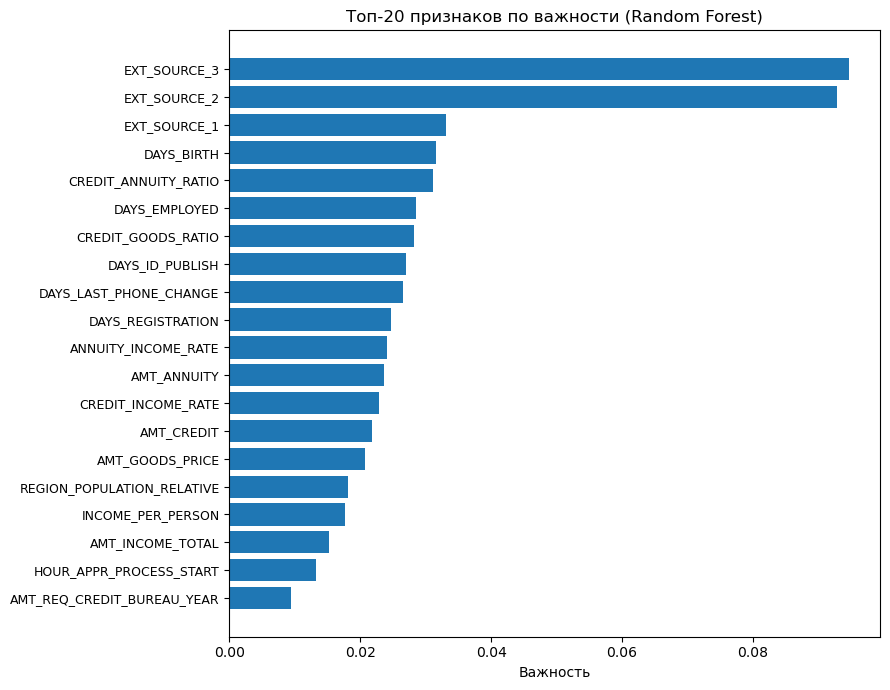

In [19]:
rf = random_search.best_estimator_.named_steps['model']
feature_names = random_search.best_estimator_.named_steps['preproc'].get_feature_names_out()
importances = pd.Series(rf.feature_importances_, index=feature_names)

top20 = importances.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(top20)), top20.values[::-1])
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.split('__')[-1] for f in top20.index[::-1]], fontsize=9)
ax.set_xlabel('Важность')
ax.set_title('Топ-20 признаков по важности (Random Forest)')
plt.tight_layout()
plt.show()

## 3. Нейронная сеть (MLP)

### 3.1 Подготовка признаков

MLP не работает с категореальными признаками явно, поэтому передаем X_selected только с числовыми признаками

In [36]:
X_selected = X[numeric]
print('признаков для MLP:', X_selected.shape[1])

признаков для MLP: 109


### 3.2 Архитектура

```
вход 109 -> 32 -> 16 -> 1
```

**Обоснование:**
- **Два скрытых слоя.** Табличные данные не требуют глубоких сетей: основная часть зависимостей
  улавливается одним-двумя нелинейными преобразованиями. Более глубокая сеть на 8% позитивного класса
  быстро уходит в переобучение.
- **Сужение 32 -> 16.** Классическая «воронка»: первый слой строит комбинации исходных признаков,
  второй сжимает их в более компактное представление перед классификацией.
- **ReLU.** Не страдает от затухания градиента в отличие от сигмоиды, стандартный выбор для скрытых слоёв.
- **Выход без активации** — один логит. Сигмоида не нужна, так как используется `BCEWithLogitsLoss`,
  которая численно устойчивее, чем связка `Sigmoid` + `BCELoss`.

**Регуляризация:** `Dropout(0.3)` после каждого скрытого слоя + ранняя остановка по `val_auc` с `patience=10`.

In [44]:
class MLP(nn.Module):
    def __init__(self, sizes, dropout=0.3):
        super().__init__()
        self.layer = nn.ModuleList([
            nn.Linear(sizes[i], sizes[i + 1]) for i in range(len(sizes) - 1)
        ])
        self.dropout = nn.ModuleList([
            nn.Dropout(dropout) for _ in range(len(sizes) - 2)
        ])
    def forward(self, x):
        for i, layer in enumerate(self.layer[:-1]):
            x = F.relu(layer(x))
            x = self.dropout[i](x)
        return self.layer[-1](x)

### 3.3 Разбиение и масштабирование

`X_selected` — это сырые колонки исходного датафрейма, в них остались пропуски,
а `StandardScaler` их не заполняет. Без импьютера `NaN` дошли бы до тензоров и loss стал бы `nan` с первой эпохи.
Импьютер и скейлер обучаются **только на train**, к валидации применяется `transform`.

In [45]:
X_tr, X_val, Y_tr, Y_val = train_test_split(X_selected, Y, stratify=Y, random_state=SEED)

imp = SimpleImputer(strategy='mean')
X_tr_i = imp.fit_transform(X_tr)
X_val_i = imp.transform(X_val)

scale = StandardScaler()
X_tr_sc = scale.fit_transform(X_tr_i)
X_val_sc = scale.transform(X_val_i)
print('NaN после импьютации:', np.isnan(X_tr_sc).sum(), np.isnan(X_val_sc).sum())
print('train:', X_tr_sc.shape, '| val:', X_val_sc.shape)

NaN после импьютации: 0 0
train: (230633, 109) | val: (76878, 109)


In [46]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(device)

sizes = [X_tr_sc.shape[1], 32, 16, 1]
model = MLP(sizes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

X_tr_t = torch.tensor(X_tr_sc, dtype=torch.float32).to(device)
Y_tr_t = torch.tensor(Y_tr.values, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val_sc, dtype=torch.float32).to(device)
Y_val_t = torch.tensor(Y_val.values, dtype=torch.float32).unsqueeze(1).to(device)

train_data = TensorDataset(X_tr_t.cpu(), Y_tr_t.cpu())
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)

mps


### 3.4 Обучение

Ранняя остановка отслеживает `val_auc`. Веса лучшей эпохи сохраняются через `copy.deepcopy`:
`state_dict()` возвращает ссылки на живые тензоры, которые `optimizer.step()` перезаписывает in-place,
поэтому без копирования в `best_state` к концу обучения оказались бы веса последней эпохи, а не лучшей.

In [47]:
n_epochs = 100
patience = 10
best_auc = 0
patience_cnt = 0
best_state = None
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

t0_total = time.time()
for epoch in range(n_epochs):
    t0 = time.time()
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_preds = torch.sigmoid(val_logits)
        val_loss = criterion(val_logits, Y_val_t).item()
        val_auc = roc_auc_score(Y_val_t.cpu().numpy(), val_preds.cpu().numpy())
    epoch_time = time.time() - t0
    history['train_loss'].append(sum(train_losses) / len(train_losses))
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    print(f"epoch {epoch + 1}: train_loss={history['train_loss'][-1]:.4f}, "
          f"val_loss={val_loss:.4f}, val_auc={val_auc:.4f}, time={epoch_time:.1f}с")
    if val_auc > best_auc:
        best_auc = val_auc
        patience_cnt = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        patience_cnt += 1
        if patience_cnt >= patience:
            print(f"Early stopping на эпохе {epoch+1}")
            model.load_state_dict(best_state)
            break

mlp_time = time.time() - t0_total
results['MLP'] = {'roc_auc': best_auc, 'time_sec': mlp_time}
print(f"\nbest val ROC_AUC mlp: {best_auc:.4f}")
print(f"общее время обучения: {mlp_time:.1f} сек ({len(history['val_auc'])} эпох)")

epoch 1: train_loss=0.2797, val_loss=0.2532, val_auc=0.7366, time=2.1с
epoch 2: train_loss=0.2609, val_loss=0.2519, val_auc=0.7403, time=2.0с
epoch 3: train_loss=0.2584, val_loss=0.2519, val_auc=0.7400, time=2.1с
epoch 4: train_loss=0.2571, val_loss=0.2515, val_auc=0.7414, time=2.1с
epoch 5: train_loss=0.2565, val_loss=0.2513, val_auc=0.7422, time=2.1с
epoch 6: train_loss=0.2551, val_loss=0.2515, val_auc=0.7417, time=2.1с
epoch 7: train_loss=0.2545, val_loss=0.2511, val_auc=0.7427, time=2.1с
epoch 8: train_loss=0.2543, val_loss=0.2506, val_auc=0.7432, time=2.1с
epoch 9: train_loss=0.2536, val_loss=0.2509, val_auc=0.7429, time=2.0с
epoch 10: train_loss=0.2536, val_loss=0.2509, val_auc=0.7426, time=2.1с
epoch 11: train_loss=0.2535, val_loss=0.2510, val_auc=0.7429, time=2.1с
epoch 12: train_loss=0.2533, val_loss=0.2511, val_auc=0.7430, time=2.0с
epoch 13: train_loss=0.2530, val_loss=0.2508, val_auc=0.7429, time=2.0с
epoch 14: train_loss=0.2531, val_loss=0.2510, val_auc=0.7428, time=2.0с
e

### 3.5 Графики обучения

Смотрим на расхождение train/val loss — главный индикатор переобучения.

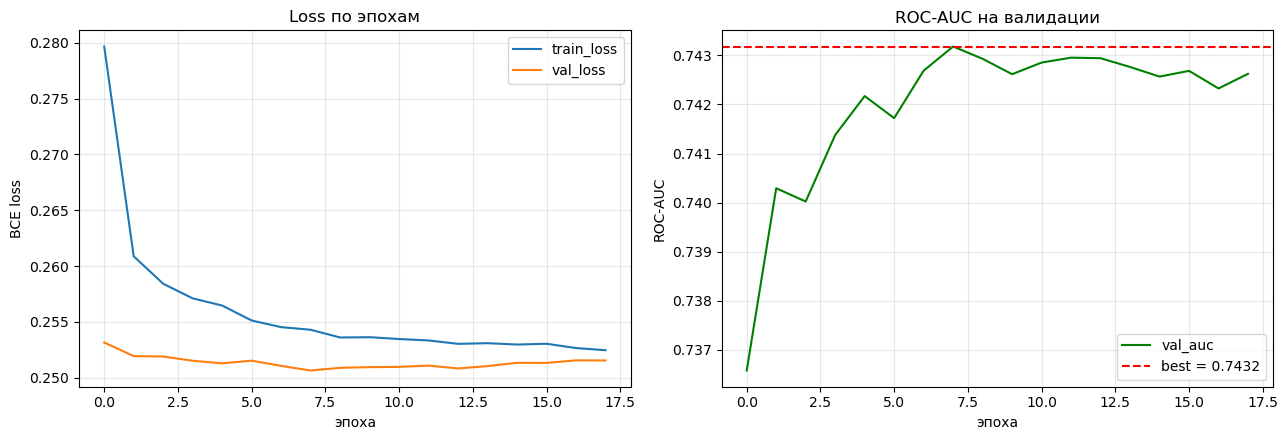

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['train_loss'], label='train_loss')
axes[0].plot(history['val_loss'], label='val_loss')
axes[0].set_xlabel('эпоха')
axes[0].set_ylabel('BCE loss')
axes[0].set_title('Loss по эпохам')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_auc'], color='green', label='val_auc')
axes[1].axhline(best_auc, color='red', linestyle='--', label=f'best = {best_auc:.4f}')
axes[1].set_xlabel('эпоха')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC на валидации')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Стекинг 

Мета-модель — логистическая регрессия поверх предсказаний трёх бустингов.
Логрегрессия выбрана намеренно: мета-модель должна быть простой, иначе она переобучится
на предсказаниях базовых моделей вместо того, чтобы найти их оптимальную взвешенную комбинацию.

`StackingClassifier` сам генерирует мета-признаки через внутреннюю кросс-валидацию,
так что предсказания для обучения мета-модели получаются out-of-fold — утечки нет.

> **О времени.** Внутренний CV на 3 фолда means каждая базовая модель обучается 3 раза.
> Оценка делается на отложенной выборке, а не внешним `cross_val_score`, — иначе базовые модели
> обучались бы 15 раз и ячейка считалась бы часы.

In [32]:
cv_stack = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

stack = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_pipe),
        ('catb', catb_pipe),
        ('xgb', xgb_pipe),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=cv_stack,
    n_jobs=1
)

X_tr2, X_te2, Y_tr2, Y_te2 = train_test_split(X, Y, stratify=Y, test_size=0.25, random_state=SEED)

t0 = time.time()
stack.fit(X_tr2, Y_tr2)
stack_auc = roc_auc_score(Y_te2, stack.predict_proba(X_te2)[:, 1])
stack_time = time.time() - t0

results['Stacking'] = {'roc_auc': stack_auc, 'time_sec': stack_time}
print(f"ROC_AUC stacking (holdout): {stack_auc:.4f}")
print(f"время обучения: {stack_time:.1f} сек")

ROC_AUC stacking (holdout): 0.7658
время обучения: 843.0 сек


## 5. Итоговое сравнение

In [49]:
res_df = pd.DataFrame(results).T
res_df['roc_auc'] = res_df['roc_auc'].astype(float).round(4)
res_df['time_sec'] = res_df['time_sec'].astype(float).round(1)
res_df['time_min'] = (res_df['time_sec'] / 60).round(1)
res_df = res_df.sort_values('roc_auc', ascending=False)
res_df

,roc_auc,time_sec,time_min
LightGBM,0.7661,1188.4,19.8
Stacking,0.7658,843.0,14.0
XGBoost,0.7588,517.7,8.6
CatBoost,0.7534,521.4,8.7
RandomForest,0.7479,782.0,13.0
LogisticRegression,0.7474,77.0,1.3
MLP,0.7432,37.0,0.6


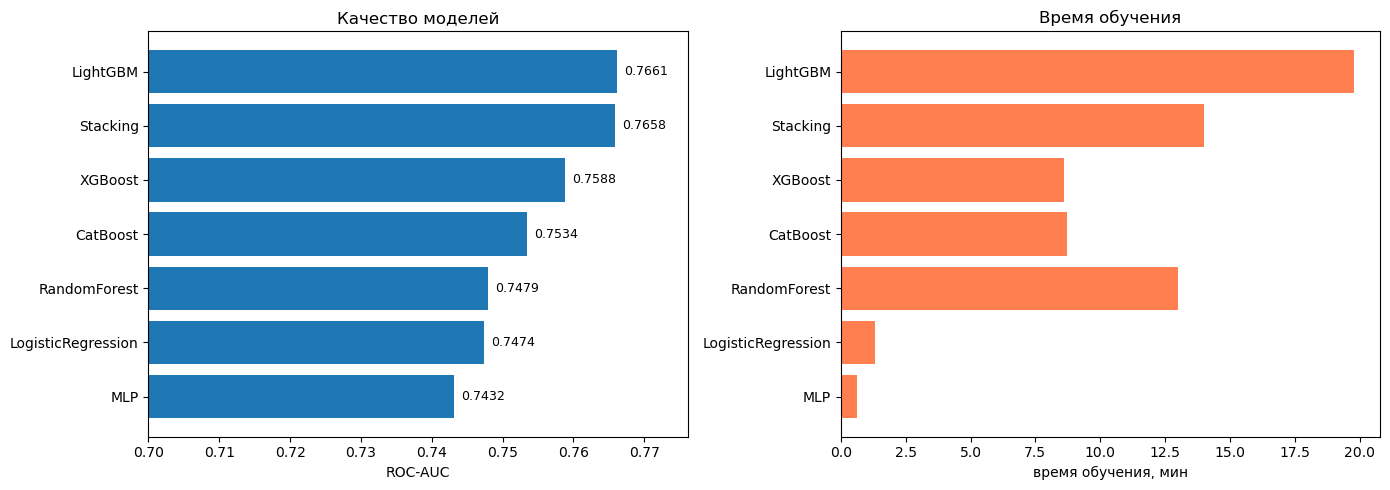

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(res_df.index[::-1], res_df['roc_auc'][::-1])
axes[0].set_xlim(0.70, res_df['roc_auc'].max() + 0.01)
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('Качество моделей')
for i, v in enumerate(res_df['roc_auc'][::-1]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va='center', fontsize=9)

axes[1].barh(res_df.index[::-1], res_df['time_min'][::-1], color='coral')
axes[1].set_xlabel('время обучения, мин')
axes[1].set_title('Время обучения')

plt.tight_layout()
plt.show()

### Ключевые замечания

**Соотношение качества и стоимости.** Логистическая регрессия даёт 0.7474 за 77 секунд, LightGBM — 0.7661 за 1188 секунд: прирост +0.019 ROC-AUC при пятнадцатикратной разнице во времени обучения. Сигнал в данных преимущественно линеен, нелинейности дают умеренную добавку поверх взвешенной суммы.

**Бустинг против бэггинга.** Random Forest (0.7479) близок к логистической регрессии: лес снижает дисперсию модели, но не смещение. Бустинг обучает каждое следующее дерево на ошибках предыдущих и снижает именно смещение, что на задаче со слабым распределённым сигналом оказывается решающим.

**Различия между бустингами объясняются настройкой.** Произведение `lr × n_estimators` составляет 17.5 у LightGBM против 5 у CatBoost и XGBoost — модели сравниваются при разном бюджете обучения. Дополнительно LightGBM оценивался по максимуму из 7 конфигураций `GridSearchCV`, что статистически смещает оценку вверх.

**Стекинг подтвердил согласованность базовых моделей.** Три бустинга на одних признаках дают близкие предсказания, их ошибки скоррелированы, поэтому ансамбль (0.7658) совпадает с лучшей одиночной моделью. 

**Регуляризация MLP отработала как задумано.** `train_loss` выше `val_loss` на протяжении всего обучения — следствие Dropout, активного на обучении и отключённого при валидации. Обе кривые сходятся к общему плато, переобучения нет. Ранняя остановка зафиксировала выход на плато, всё обучение уложилось в 37 секунд.

**Отбор признаков подтвердил ценность полного набора.** Оптимальным значением `max_features` оказалось `None`: при слабом распределённом сигнале каждый признак вносит небольшой вклад, и полный набор работает лучше сокращённого.

**Feature engineering подтвердил исходную гипотезу.** Все пять сконструированных отношений вошли в топ-20 по важности, `CREDIT_ANNUITY_RATIO` занял 5-е место — выше, чем `AMT_ANNUITY` (12-е) и `AMT_CREDIT` (14-е), из которых он построен. В кредитном скоринге относительные величины информативнее абсолютных сумм.

## Итоги

Построен полный пайплайн бинарной классификации для задачи кредитного скоринга: **307 511 объектов, 120 признаков, доля положительного класса 8.07%**, линейные корреляции признаков с целевой переменной не превышают 0.18 по модулю.

- Проведён EDA, обработка пропусков (67 колонок) и выбросов, кодирование категориальных признаков, feature engineering — все 5 сконструированных признаков вошли в топ-20 по важности.
- Вся предобработка оформлена через `Pipeline` и `ColumnTransformer` с раздельными стратегиями для бинарных, числовых и категориальных признаков, что исключает утечку данных на кросс-валидации.
- Обучены и сравнены **LightGBM, CatBoost, XGBoost, Random Forest, Logistic Regression, MLP и stacking-ансамбль** на стратифицированной 5-фолдовой кросс-валидации; подбор гиперпараметров выполнен через `GridSearchCV` и `RandomizedSearchCV`, отбор признаков — через `SelectFromModel`.
- Нейросеть реализована на PyTorch с Dropout и ранней остановкой, обучение на GPU Apple Silicon (`mps`).
- Лучший результат: **ROC-AUC 0.7661** (LightGBM); стекинг трёх бустингов — 0.7658. Логистическая регрессия достигает 0.7474 за 77 секунд против 1188 секунд у LightGBM, что даёт ориентир по соотношению качества и вычислительной стоимости.

**Применённые навыки:** pandas, numpy, matplotlib, scikit-learn (Pipeline, ColumnTransformer, кросс-валидация, подбор гиперпараметров, отбор признаков, стекинг), LightGBM, CatBoost, XGBoost, PyTorch, EDA, feature engineering, работа с несбалансированными выборками, анализ важности признаков.